## Exercise 1

### Part 1

In [ ]:
import numpy as np

# Function:
def lcg(x0, a, c, M, n):
    """
    x0: 'int'
    The initial value for the LCG
    a: 'int'
    The multiplier
    c: 'int'
    The increment
    M: 'int'
    The modulus
    n: 'int' 
    Number of numbers to generate

    Returns
    'np.ndarray[float]'
    A numpy array with the generated sequence

    """

    # Initialize sequence
    seq = np.zeros(n, dtype=np.uint64)

    # Set initial value to x0
    seq[0] = x0

    # Generate sequence
    for i in range(1, n):
        seq[i] = (a * seq[i - 1] + c) % M

    # Normalize and return the result
    return seq / M


In [47]:
# Implement the function:
# Parameters
x0 = 3
a = 5
c = 1
M = 16
n = 10000

# Generate sequence
data = lcg(x0, a, c, M, n)
random_seq = data

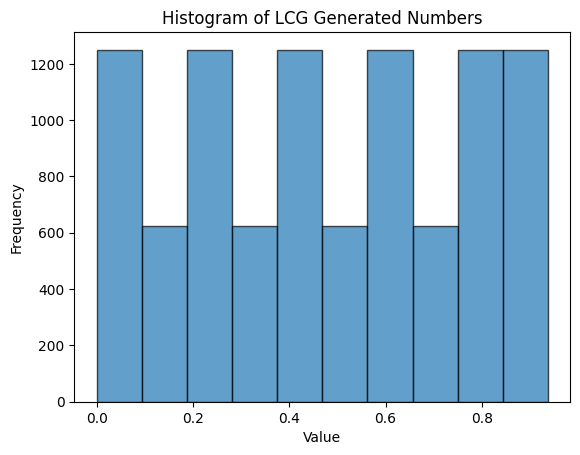

In [48]:
import matplotlib.pyplot as plt

# Plotting the histogram
plt.hist(random_seq, bins=10, edgecolor='black', alpha=0.7)
plt.title("Histogram of LCG Generated Numbers")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

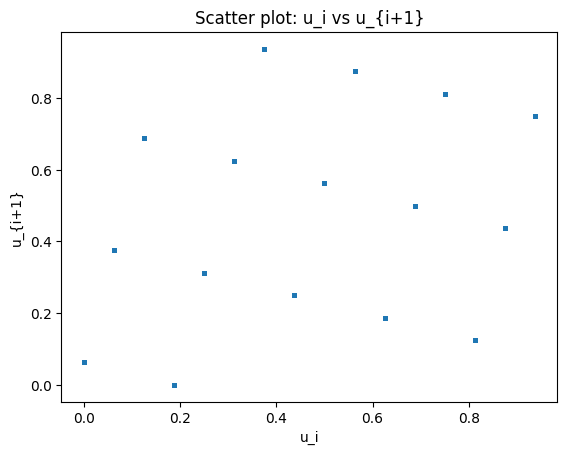

In [49]:
plt.scatter(data[:-1], data[1:], s=5)
plt.title("Scatter plot: u_i vs u_{i+1}")
plt.xlabel("u_i")
plt.ylabel("u_{i+1}")
plt.show()

In [50]:
# Chi-square test
def chi_square_test(data, k=10):
    """
    Chi-square test for uniformity on [0,1]
    """

    n = len(data)

    # Count observations directly into bins
    observed = np.zeros(k)

    for x in data:
        idx = int(x * k)
        if idx == k:
            idx = k - 1
        observed[idx] += 1

    expected = n / k

    chi2 = np.sum((observed - expected) ** 2 / expected)

    return chi2

# Run the function on the data
chi2 = chi_square_test(data, k=10)
print("Chi-square statistic:", chi2)

Chi-square statistic: 937.5


In [51]:
# ks statistic
def ks_test(data):
    """
    Kolmogorov-Smirnov test for Uniform(0,1)
    """

    x = np.sort(data)
    n = len(x)

    d_plus = 0
    d_minus = 0

    for i in range(n):
        d_plus = max(d_plus, (i + 1) / n - x[i])
        d_minus = max(d_minus, x[i] - i / n)

    return max(d_plus, d_minus)

# Run the function on the data
ks = ks_test(data)
print("KS statistic:", ks)

KS statistic: 0.0625


In [52]:
# Run test
def runs_test(data):
    """
    Runs test based on median split
    """

    median = np.median(data)

    seq = [1 if x >= median else 0 for x in data]

    runs = 1
    for i in range(1, len(seq)):
        if seq[i] != seq[i - 1]:
            runs += 1

    n1 = sum(seq)
    n2 = len(seq) - n1

    expected = (2 * n1 * n2) / (n1 + n2) + 1

    variance = (
        2 * n1 * n2 * (2 * n1 * n2 - n1 - n2)
        / ((n1 + n2) ** 2 * (n1 + n2 - 1))
    )

    z = (runs - expected) / np.sqrt(variance)

    return runs, z

# Run the function on the data
runs, z = runs_test(data)
print("Number of runs:", runs)
print("Z-score:", z)

Number of runs: 3750
Z-score: -25.0212512189641


In [53]:
# Correlation test
def correlation_test(data, h):
    """
    Lag-h correlation test
    """

    n = len(data)
    mean = np.mean(data)

    num = 0
    den = 0

    for i in range(n - h):
        num += (data[i] - mean) * (data[i + h] - mean)

    for i in range(n):
        den += (data[i] - mean) ** 2

    return num / den

# Run the test on the data
for h in [1, 2, 5, 10]:
    r = correlation_test(data, h)
    print(f"Correlation (h={h}):", r)

Correlation (h=1): 0.2706411764705882
Correlation (h=2): -0.035258823529411766
Correlation (h=5): 0.08226
Correlation (h=10): -0.03549411764705882


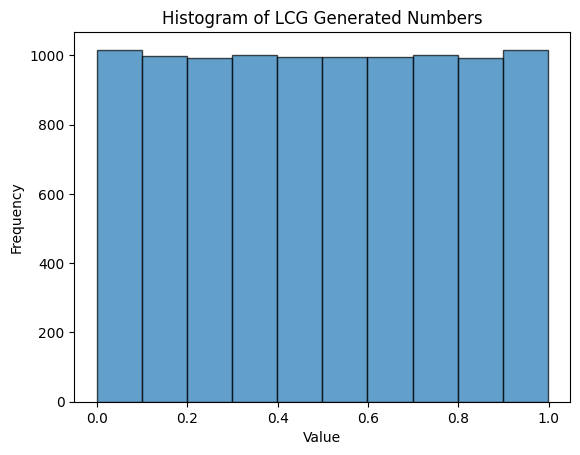

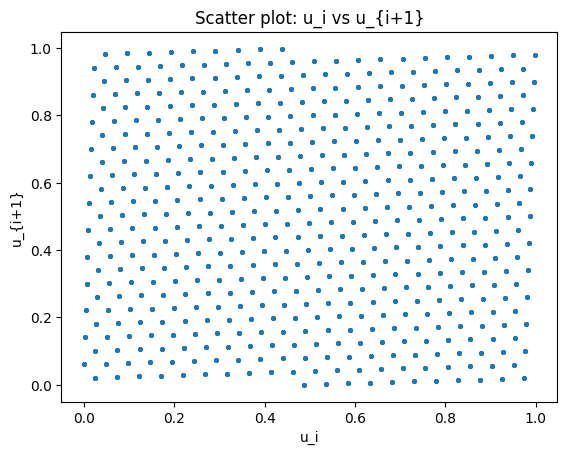

Chi-square statistic: 0.5900000000000001
KS statistic: 0.0026343749999999666
Number of runs: 5036
Z-score: 0.7013401612150462
Correlation (h=1): 0.003557972871034175
Correlation (h=2): -0.0024034939623230884
Correlation (h=5): 0.0013629130981640287
Correlation (h=10): 0.010911348709882538


In [54]:
# Test different values
x0 = 3
a = 41
c = 31
M = 512
n = 10000

# Generate sequence
data = lcg(x0, a, c, M, n)
random_seq = data

# Plot histogram and scatter plot
plt.hist(random_seq, bins=10, edgecolor='black', alpha=0.7)
plt.title("Histogram of LCG Generated Numbers")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

plt.scatter(data[:-1], data[1:], s=5)
plt.title("Scatter plot: u_i vs u_{i+1}")
plt.xlabel("u_i")
plt.ylabel("u_{i+1}")
plt.show()

# Run tests
chi2 = chi_square_test(data, k=10)
print("Chi-square statistic:", chi2)

ks = ks_test(data)
print("KS statistic:", ks)

runs, z = runs_test(data)
print("Number of runs:", runs)
print("Z-score:", z)

for h in [1, 2, 5, 10]:
    r = correlation_test(data, h)
    print(f"Correlation (h={h}):", r)


Based on the plots as well as the statistics, the second choise of values appears to be an improvement from the first.

### Part 2

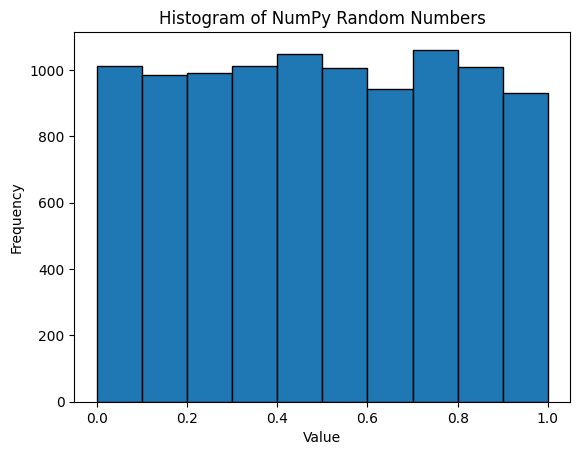

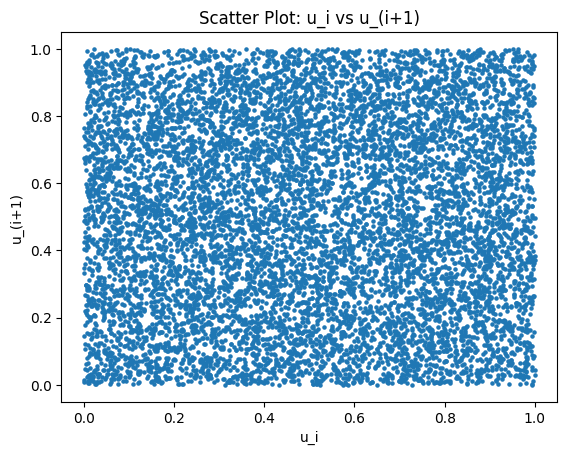

Chi-square statistic: 14.469999999999999
KS statistic: 0.008179520562742515
Number of runs: 5069
Z-score: 1.3600680119021253
Correlation (h=1): 0.005011168430651003
Correlation (h=2): 0.006478037459818631
Correlation (h=5): 0.011437891551853143
Correlation (h=10): 0.012603461029617518


In [ ]:
# Generate numbers
n = 10000
system_data = np.random.random(n)

# Plot histogram and scatter plot
plt.hist(system_data, bins=10, edgecolor='black')
plt.title("Histogram of NumPy Random Numbers")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

plt.scatter(system_data[:-1], system_data[1:], s=5)
plt.title("Scatter Plot: u_i vs u_(i+1)")
plt.xlabel("u_i")
plt.ylabel("u_(i+1)")
plt.show()

# Run tests
print("Chi-square statistic:", chi_square_test(system_data))

print("KS statistic:", ks_test(system_data))

runs, z = runs_test(system_data)

print("Number of runs:", runs)
print("Z-score:", z)

for h in [1, 2, 5, 10]:
    print(f"Correlation (h={h}):", correlation_test(system_data, h))

### Part 3

The tests done in the first two parts were based on a single sample of 10000 pteudo-random numbers, which is generally not sufficient to fully assess the quality of the random number generator, since stastictical test results are subject to random variation. 

In order to improve this, one could generate multiple independent samples and do statistical tests for each. The distribution of these test statistic results can then be exaimed though measures such as mean and standard deviation. 

In [ ]:
import numpy as np

# Function:
def lcg(x0, a, c, M, n):
    """
    x0: 'int'
    The initial value for the LCG
    a: 'int'
    The multiplier
    c: 'int'
    The increment
    M: 'int'
    The modulus
    n: 'int' 
    Number of numbers to generate

    Returns
    'np.ndarray[float]'
    A numpy array with the generated sequence

    """

    # Initialize sequence
    seq = np.zeros(n, dtype=np.uint64)

    # Set initial value to x0
    seq[0] = x0

    # Generate sequence
    for i in range(1, n):
        seq[i] = (a * seq[i - 1] + c) % M

    # Normalize and return the result
    return seq / M

# Here the experiment is repeated for 50 different seeds, and the resulting chi-square statistics are analyzed
x0 = 3
a = 41
c = 31
M = 512
n = 10000

chi2_values = []

for seed in range(50):

    data = lcg(seed + 1, a, c, M, n)

    chi2_values.append(
        chi_square_test(data)
    )

print("Average chi-square:", np.mean(chi2_values))
print("Std. deviation:", np.std(chi2_values))

Average chi-square: 0.75692
Std. deviation: 0.06294150935590918
